#Hotel-A Train

## Phase 1: Pre-Cleaning EDA (Data Profiling)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Data Loading

In [ ]:
#loading dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DPLC/CW/raw/Hotel-A-train.csv')

In [ ]:
df.head()

,Reservation-id,Gender,Age,Ethnicity,Educational_Level,Income,Country_region,Hotel_Type,Expected_checkin,Expected_checkout,...,Meal_Type,Visted_Previously,Previous_Cancellations,Deposit_type,Booking_channel,Required_Car_Parking,Reservation_Status,Use_Promotion,Discount_Rate,Room_Rate
0,39428300,F,40,Latino,Grad,<25K,North,City Hotel,7/1/2015,7/2/2015,...,BB,No,No,No Deposit,Online,Yes,Check-Out,Yes,10,218
1,77491756,F,49,Latino,Mid-School,50K -- 100K,East,City Hotel,7/1/2015,7/2/2015,...,BB,No,No,Refundable,Online,Yes,Check-Out,No,0,185
2,73747291,F,42,caucasian,Grad,<25K,East,City Hotel,7/2/2015,7/6/2015,...,BB,No,No,No Deposit,Online,Yes,Check-Out,No,0,119
3,67301739,M,25,African American,College,>100K,South,Airport Hotels,7/2/2015,7/3/2015,...,BB,No,No,Refundable,Agent,Yes,Check-Out,Yes,5,144
4,77222321,F,62,Latino,High-School,25K --50K,East,Resort,7/3/2015,7/4/2015,...,BB,No,No,No Deposit,Direct,No,Check-Out,Yes,10,242


### Basic Overview

In [ ]:
df.shape

(27499, 24)

In [ ]:
#exploring datatypes of each variable, number of fields and rows
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27499 entries, 0 to 27498
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Reservation-id          27499 non-null  int64 
 1   Gender                  27499 non-null  object
 2   Age                     27499 non-null  int64 
 3   Ethnicity               27499 non-null  object
 4   Educational_Level       27499 non-null  object
 5   Income                  27499 non-null  object
 6   Country_region          27499 non-null  object
 7   Hotel_Type              27499 non-null  object
 8   Expected_checkin        27499 non-null  object
 9   Expected_checkout       27499 non-null  object
 10  Booking_date            27499 non-null  object
 11  Adults                  27499 non-null  int64 
 12  Children                27499 non-null  int64 
 13  Babies                  27499 non-null  int64 
 14  Meal_Type               27499 non-null  object
 15  Vi

Date/time data (expected_chechin, expected_checkout, booking_date) has been stored in object form, which will cause issues because the data will be treated as text.
Therefore, it will not show trends or help identify seasonality.  

In [ ]:
#checking for null values
df.isnull().sum()

,0
Reservation-id,0
Gender,0
Age,0
Ethnicity,0
Educational_Level,0
Income,0
Country_region,0
Hotel_Type,0
Expected_checkin,0
Expected_checkout,0


In [ ]:
#checking for duplicates for reservation id only  as it is assumed to be a unique value
duplicate_count = df.duplicated(subset=['Reservation-id']).sum()
duplicate_count

np.int64(4)

Identified 4 duplicates in the reservation ID column. This overrules the function of the ID column being a primary key and shows that either there is a duplicate entry in the dataset or the ID is not meant for that record.

### Summary Statistics

In [ ]:
#descriptive statistics of numerical variables
df.describe()

,Reservation-id,Age,Adults,Children,Babies,Discount_Rate,Room_Rate
count,2.749900e+04,27499.000000,27499.000000,27499.000000,27499.000000,27499.000000,27499.000000
mean,5.016461e+07,43.977454,2.333576,1.743882,0.351540,12.495182,175.136478
std,2.886911e+07,15.303148,1.176526,0.721972,0.573326,11.206036,43.877087
min,3.154000e+03,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000
25%,2.523943e+07,31.000000,2.000000,1.000000,0.000000,5.000000,137.000000
50%,5.014996e+07,44.000000,2.000000,2.000000,0.000000,10.000000,175.000000
75%,7.518288e+07,57.000000,3.000000,2.000000,1.000000,20.000000,214.000000
max,9.999900e+07,70.000000,5.000000,3.000000,2.000000,40.000000,250.000000


**Age:** Average guest age is 44, with most falling between 31 and 57.

**Adults:** Most booking are made by couples.

**Children & Babies:** The dataset consists of many family bookings. Moreover, the max number shows that some rooms have up to 5 adults and 3 children. This violates the booking policy of 5 people per room.  


**Room Rate:** average price is $175.14 and there are no outliers. Therefore, the dataset consists of standard hotel rooms, no luxury bookings.  

**Discount rate:** average discount rate is 12.5%. However, the maximum discount rate of 40% shows that some customers are getting almost half off on bookings.



In [ ]:
#descriptive statistics of catergorical variables
df.describe(include=['object'])

,Gender,Ethnicity,Educational_Level,Income,Country_region,Hotel_Type,Expected_checkin,Expected_checkout,Booking_date,Meal_Type,Visted_Previously,Previous_Cancellations,Deposit_type,Booking_channel,Required_Car_Parking,Reservation_Status,Use_Promotion
count,27499,27499,27499,27499,27499,27499,27499,27499,27499,27499,27499,27499,27499,27499,27499,27499,27499
unique,2,4,4,4,4,3,901,929,1133,3,2,2,3,3,2,4,2
top,F,African American,College,50K -- 100K,South,Airport Hotels,2/9/2016,3/14/2016,10/19/2015,BB,No,No,No Deposit,Online,Yes,Check-Out,Yes
freq,13799,6965,11052,7936,10917,9258,145,91,232,14224,18344,24379,18244,15574,19629,19092,20670


The data consists of mostly new customers who are from the *African American* ethnicity.

**LEAD TIME** - booking date(oct 2015) expected_checking(feb 2016) Long booking windows

Online Booking is the most dominant and most *do not have deposits*.

Customer base is also highly price sensitive since most are made after discounts.



### Categorical variables check

In [ ]:
# checking for casing inconsistencies in categorical variables
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    print(df[col].value_counts())
    print("\n")

Gender
F    13799
M    13700
Name: count, dtype: int64


Ethnicity
African American    6965
caucasian           6890
Asian American      6838
Latino              6806
Name: count, dtype: int64


Educational_Level
College        11052
High-School     5522
Mid-School      5481
Grad            5444
Name: count, dtype: int64


Income
50K -- 100K    7936
25K --50K      7870
<25K           7739
>100K          3954
Name: count, dtype: int64


Country_region
South    10917
North     5670
East      5460
West      5452
Name: count, dtype: int64


Hotel_Type
Airport Hotels    9258
City Hotel        9134
Resort            9107
Name: count, dtype: int64


Expected_checkin
2/9/2016      145
2/29/2016     129
11/15/2015    124
12/8/2015     115
4/4/2016      110
             ... 
2/24/2015       1
2/12/2015       1
8/12/2017       1
1/28/2015       1
6/14/2015       1
Name: count, Length: 901, dtype: int64


Expected_checkout
3/14/2016    91
2/10/2016    91
1/23/2016    88
3/25/2016    88
4/5/2016   

Region: South is a massive outlier and contirbuted to nearly 40% of all bookings while the other three regions are similar in size.

Business heavily relies on new customers (only 33% have visited previously).



### Univariate Analysis

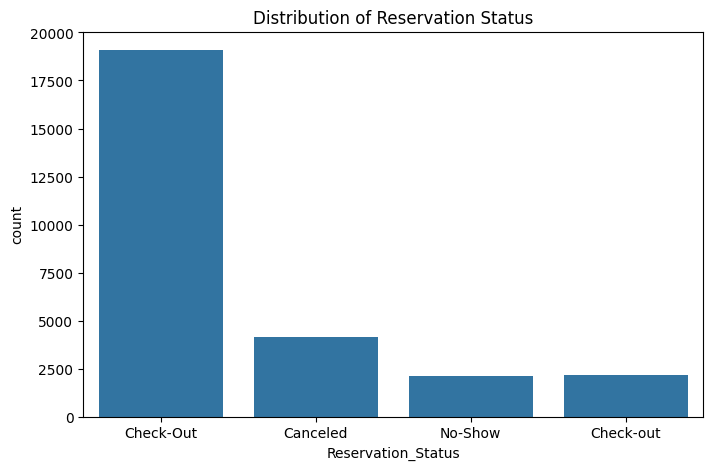

In [ ]:
#Visualising to check for incosistenies in reservation status
plt.figure(figsize=(8, 5))
sns.countplot(x='Reservation_Status', data=df)
plt.title('Distribution of Reservation Status')
plt.show()

Identified case sensitivity error. Check-out and Check-Out are being treated as different categories.

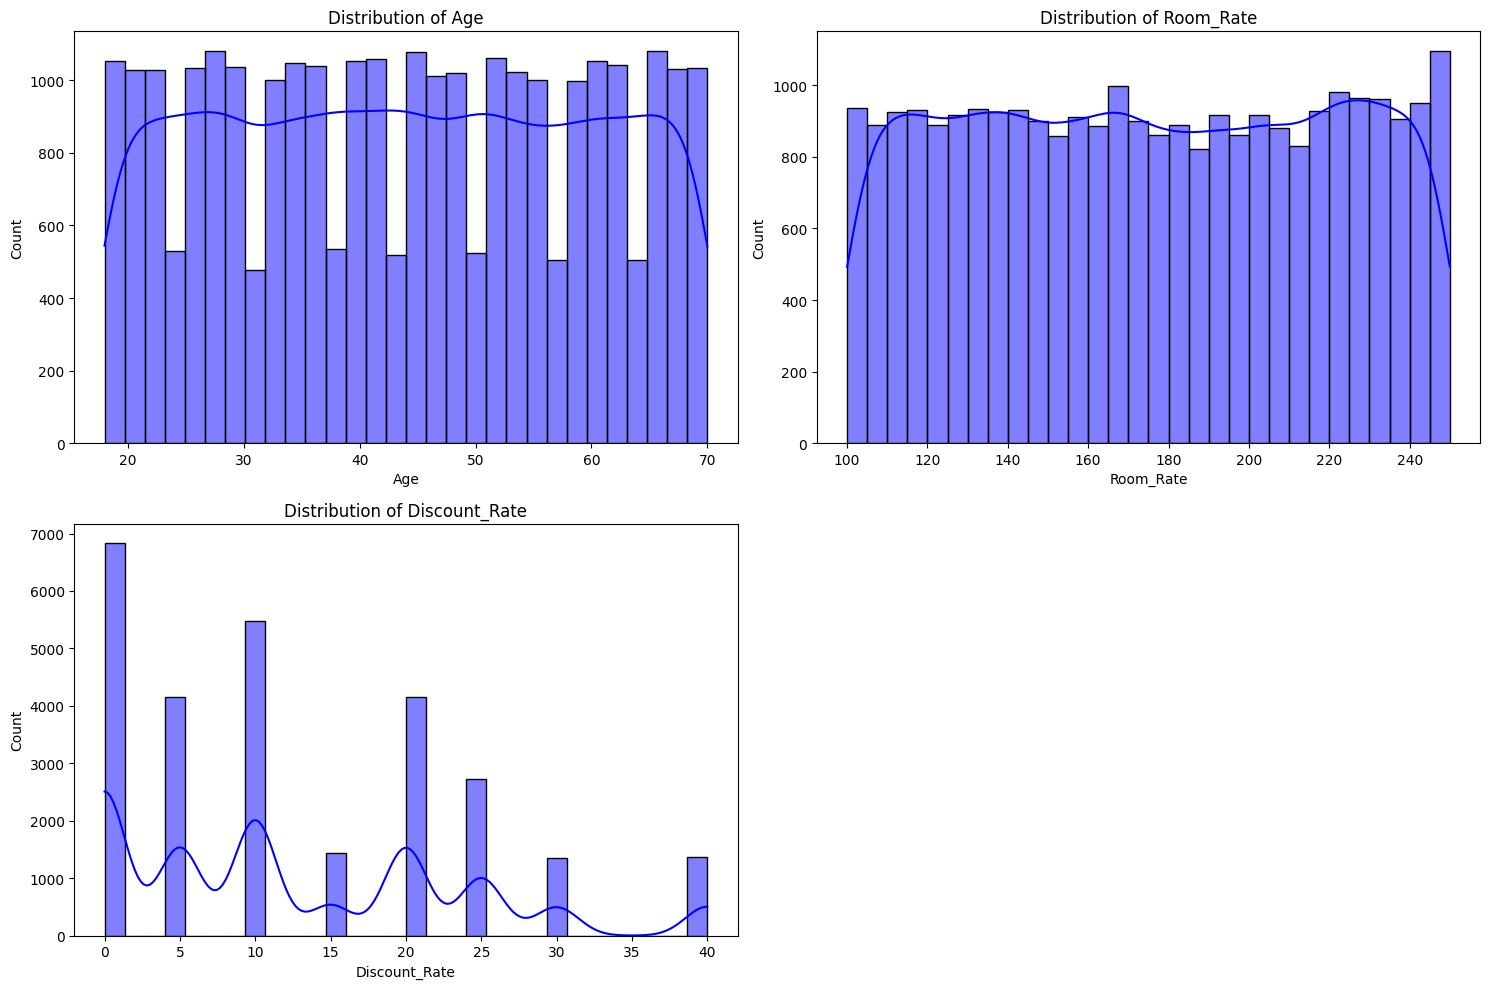

In [ ]:
#Numerical Variables: Histograms
num_vars = ['Age', 'Room_Rate', 'Discount_Rate']
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_vars, 1):
    if col in df.columns:
        plt.subplot(2, 2, i)
        sns.histplot(df[col], bins=30, kde=True, color='blue')
        plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

A very balanced and uniform dataset.
Discount rate follows realistic patterns with peaks at normal fixed discount rates (0,10,20,25)

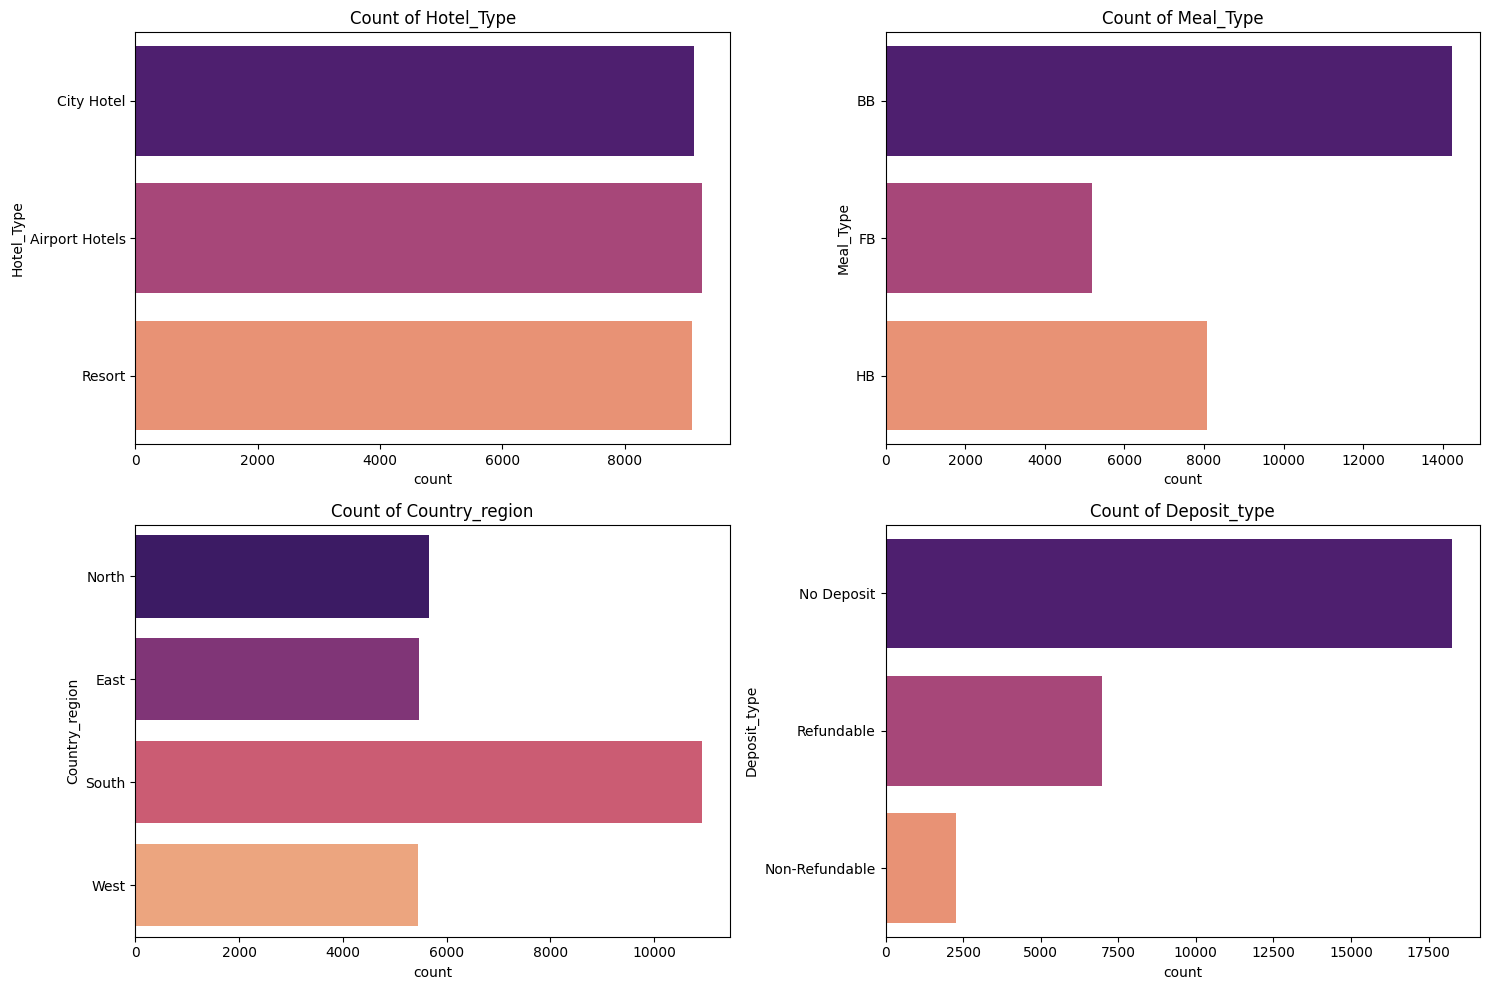

In [ ]:
#Categorical Variables: Bar Charts
cat_vars = ['Hotel_Type', 'Meal_Type', 'Country_region', 'Deposit_type']
plt.figure(figsize=(15, 10))
for i, col in enumerate(cat_vars, 1):
    if col in df.columns:
        plt.subplot(2, 2, i)
        sns.countplot(y=col, data=df, hue=col, legend=False, palette='magma')
        plt.title(f'Count of {col}')
plt.tight_layout()
plt.show()

The south region has the highest impact in this dataset along with the meal type BB.

Deposit Type is mostly "no deposit". Thus depicting reasons for no-shows or cancellations.


### Bivariate Analysis

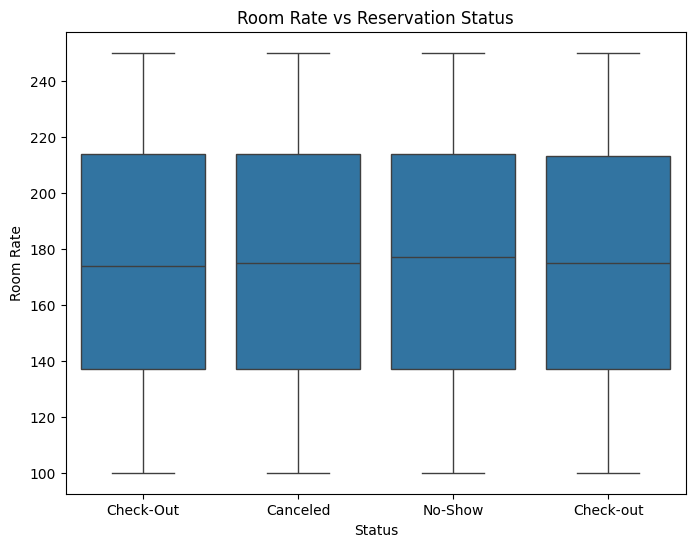

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Reservation_Status', y='Room_Rate', data=df)
plt.title('Room Rate vs Reservation Status')
plt.xlabel('Status')
plt.ylabel('Room Rate')
plt.show()

Guests are not cancelling due to high prices because the distribution is almost identical.

<Figure size 1000x600 with 0 Axes>

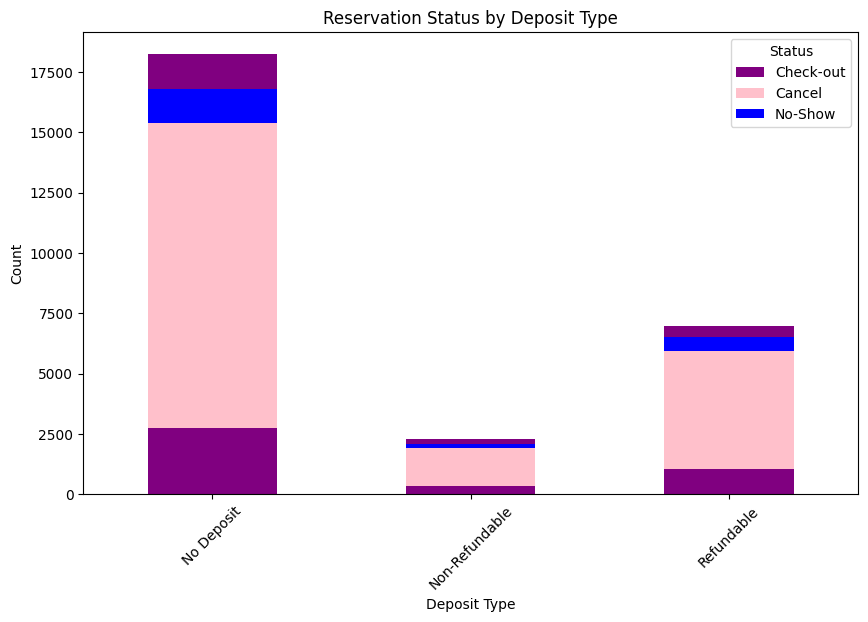

In [ ]:
#Status vs Deposit Type
plt.figure(figsize=(10, 6))
deposit_status = pd.crosstab(df['Deposit_type'], df['Reservation_Status'])
deposit_status.plot(kind='bar', stacked=True, figsize=(10, 6), color=['purple', 'pink', 'blue'])
plt.title('Reservation Status by Deposit Type')
plt.xlabel('Deposit Type')
plt.ylabel('Count')
plt.legend(title='Status', labels=['Check-out', 'Cancel', 'No-Show'])
plt.xticks(rotation=45)
plt.show()

There are more cancellations than no-shows in all three deposit types. However, no deposit has the highest cancelled status.

Non refundable deposites also have high cancellation rates. Proving it doesn't have an impact on the customer base.

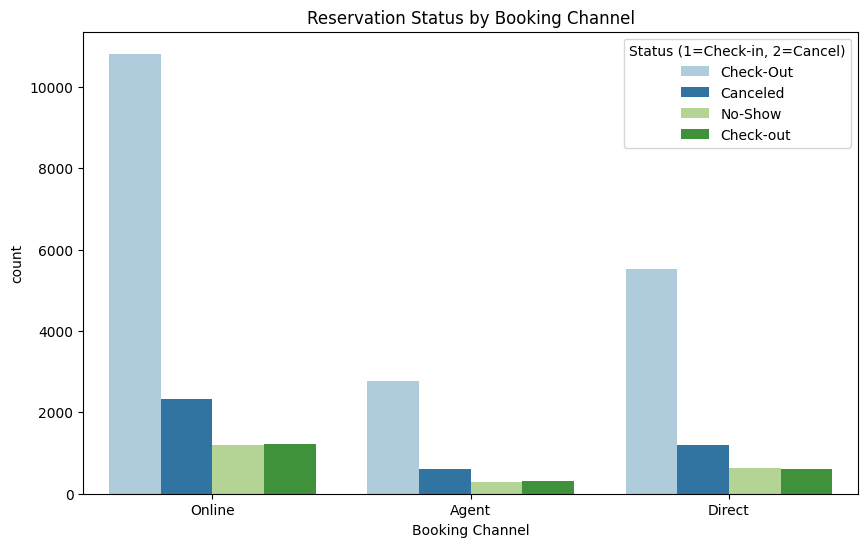

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Booking_channel', hue='Reservation_Status', data=df, palette='Paired')
plt.title('Reservation Status by Booking Channel')
plt.xlabel('Booking Channel')
plt.legend(title='Status (1=Check-in, 2=Cancel)')
plt.show()

Online and direct booking have the most check-out stages. Direct booking have the most reliable bookings.

Agent mediated bookings bring in less guests while also having a higher rate of cancellation and no-shows.

### Multivariate Analysis

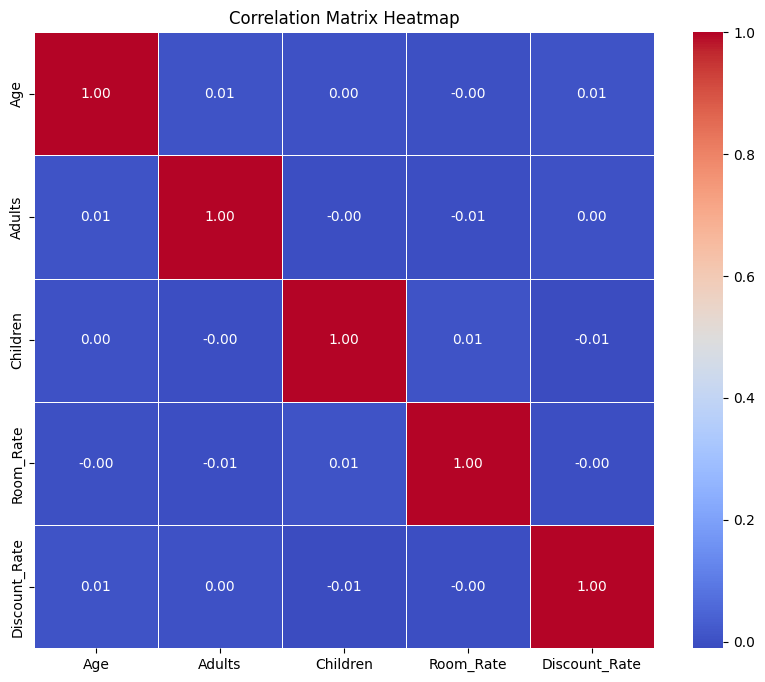

In [ ]:
corr_cols = ['Age', 'Adults', 'Children', 'Room_Rate', 'Discount_Rate']
corr_data = df[corr_cols]
corr_matrix = corr_data.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

Numerical features are independant from each other with online booking bringing the most successful checkouts.

The independant features shows that older guests are not booking more expensive rooms or higher room rates dont have bigger discounts.

### Outlier Check

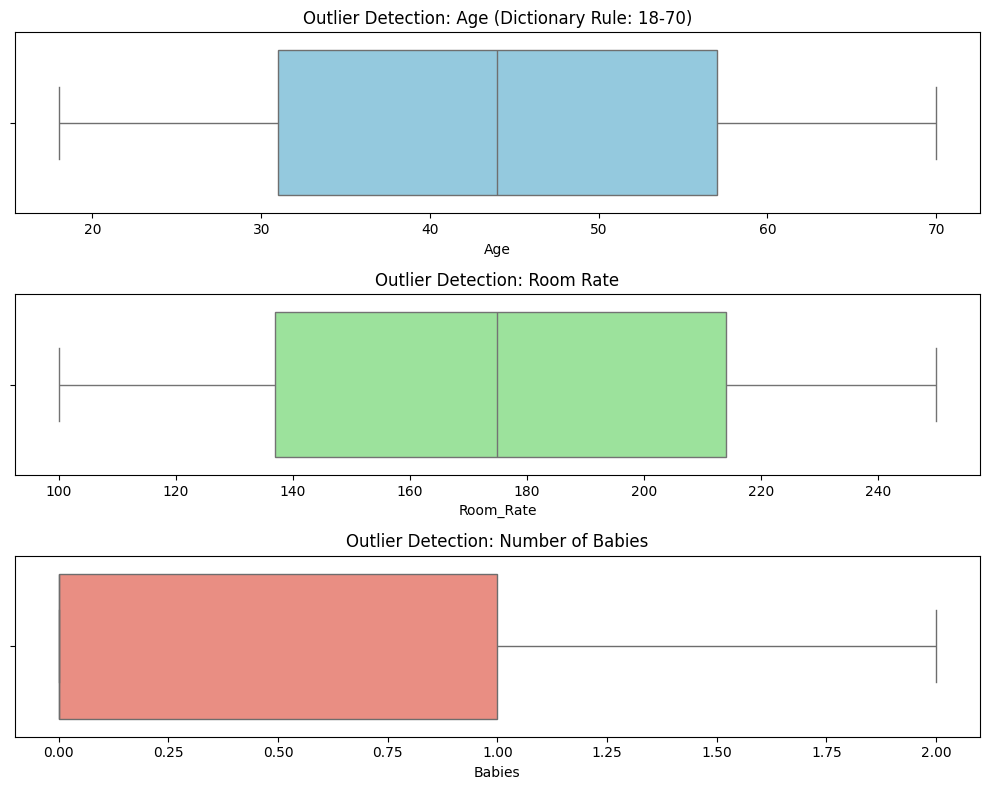

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8))

# 1. Check Age
sns.boxplot(x=df['Age'], ax=axes[0], color='skyblue')
axes[0].set_title('Outlier Detection: Age (Dictionary Rule: 18-70)')

# 2. Check Room Rate
sns.boxplot(x=df['Room_Rate'], ax=axes[1], color='lightgreen')
axes[1].set_title('Outlier Detection: Room Rate')

# 3. Check Babies
sns.boxplot(x=df['Babies'], ax=axes[2], color='salmon')
axes[2].set_title('Outlier Detection: Number of Babies')

plt.tight_layout()
plt.show()

Age and room rate is uniform with no outliers.

Babies is heavily right skewed with a few rare occurences.

### Business Rule Validation (Data Dictionary Checks)

In [ ]:
#Calculating total number of guests (Adults + Children only) to find rows where Adults + Children > 5
overcapacity_filter = (df['Adults'] + df['Children']) > 5
df.loc[overcapacity_filter, ['Reservation-id', 'Adults', 'Children']]

,Reservation-id,Adults,Children
1,77491756,3,3
2,73747291,3,3
3,67301739,4,3
5,55152245,5,2
11,41573356,4,3
...,...,...,...
27442,89684505,5,1
27467,89678238,4,2
27468,23841411,3,3
27488,85704206,4,2


Shows overcapacity identified where bookings of greater than 5 people per room has been made.

Possible driver of cancellations.

In [ ]:
#check for invalid ages (less than 18 OR greater than 70)
age_filter = (df['Age'] < 18) | (df['Age'] > 70)
df.loc[age_filter, ['Reservation-id', 'Age']]

,Reservation-id,Age


## Phase 2: Data Cleaning

In [ ]:
# convert categorical col into upper case
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()

In [ ]:
print(df['Reservation_Status'].unique())

['check-out' 'canceled' 'no-show']


In [ ]:
# Unifying the 'Success' labels (after converting to uppercase in a previous step)
df['Reservation_Status'] = df['Reservation_Status'].replace('CHECK-IN','CHECK-OUT')

In [ ]:
# 3. handle date conversions
date_columns = ['Expected_checkin', 'Expected_checkout', 'Booking_date']

for col in date_columns:
    # errors='coerce' turns completely broken dates into NaT (Not a Time)
    df[col] = pd.to_datetime(df[col], errors='coerce')

In [ ]:
# 4. Handling Duplicates
df = df.drop_duplicates(subset=['Reservation-id'], keep='first')
print(f"Remaining duplicate IDs: {df.duplicated(subset=['Reservation-id']).sum()}")

Remaining duplicate IDs: 0


## Feature Engineering

In [ ]:
df['Lead_Time'] = (df['Expected_checkin'] - df['Booking_date']).dt.days

In [ ]:
df['Length_of_Stay'] = (df['Expected_checkout'] - df['Expected_checkin']).dt.days

In [ ]:
df['Total_Guests'] = df['Adults'] + df['Children']
df.drop(['Adults', 'Children', 'Babies'], axis=1, inplace=True)

In [ ]:
df['Checkin_Month'] = df['Expected_checkin'].dt.month

In [ ]:
df['Is_Weekend'] = df['Expected_checkin'].dt.weekday.isin([5, 6]).astype(int)

In [ ]:
# Drop rows where Booking Date is - after Check-in (invalid data)
df = df[df['Lead_Time'] >= 0].copy()

## Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
df['Reservation_Status'].unique()

array(['check-out', 'canceled', 'no-show'], dtype=object)

In [ ]:
# 1. Encode Target (Reservation_Status)
# Mapping: CHECK-IN: 1, CANCELED: 2, NO-SHOW: 3 (keys adjusted to match uppercase values)
target_mapping = {'check-out': 1, 'canceled': 2, 'no-show': 3}
df['Reservation_Status'] = df['Reservation_Status'].map(target_mapping)

In [ ]:
# 2. Encode Categorical Features
# Identify columns that are objects

categorical_features = df.select_dtypes(include=['object']).columns.tolist()
if 'Reservation-id' in categorical_features: categorical_features.remove('Reservation-id')

train_final = pd.get_dummies(df, columns=categorical_features, drop_first=True)

In [ ]:
train_final.head()

,Reservation-id,Age,Expected_checkin,Expected_checkout,Booking_date,Reservation_Status,Discount_Rate,Room_Rate,Lead_Time,Length_of_Stay,...,Meal_Type_fb,Meal_Type_hb,Visted_Previously_yes,Previous_Cancellations_yes,Deposit_type_non-refundable,Deposit_type_refundable,Booking_channel_direct,Booking_channel_online,Required_Car_Parking_yes,Use_Promotion_yes
0,39428300,40,2015-07-01,2015-07-02,2015-05-21,1,10,218,41,1,...,False,False,False,False,False,False,False,True,True,True
1,77491756,49,2015-07-01,2015-07-02,2015-05-26,1,0,185,36,1,...,False,False,False,False,False,True,False,True,True,False
2,73747291,42,2015-07-02,2015-07-06,2015-06-29,1,0,119,3,4,...,False,False,False,False,False,False,False,True,True,False
3,67301739,25,2015-07-02,2015-07-03,2015-06-20,1,5,144,12,1,...,False,False,False,False,False,True,False,False,True,True
4,77222321,62,2015-07-03,2015-07-04,2015-06-20,1,10,242,13,1,...,False,False,False,False,False,False,True,False,False,True


In [ ]:
import numpy as np

# Create Lead Time Categories
# 0-7 days: Last Minute (Low Cancel)
# 7-30 days: Short Term
# 30-90 days: Medium Term
# 90+ days: Long Term (High Cancel Risk)
df['Lead_Time_Category'] = pd.cut(df['Lead_Time'],
                                  bins=[-np.inf, 7, 30, 90, np.inf],
                                  labels=['Last_Minute', 'Short_Term', 'Medium_Term', 'Long_Term'])

In [ ]:
train_final.to_csv('Hotel_A_Train_Cleaned.csv', index=False)

In [ ]:
from google.colab import files

# This will trigger a browser download for the file
files.download('Hotel_A_Train_Cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df

,Reservation-id,Gender,Age,Ethnicity,Educational_Level,Income,Country_region,Hotel_Type,Expected_checkin,Expected_checkout,...,Reservation_Status,Use_Promotion,Discount_Rate,Room_Rate,Lead_Time,Length_of_Stay,Total_Guests,Checkin_Month,Is_Weekend,Lead_Time_Category
0,39428300,f,40,latino,grad,<25k,north,city hotel,2015-07-01,2015-07-02,...,1,yes,10,218,41,1,4,7,0,Medium_Term
1,77491756,f,49,latino,mid-school,50k -- 100k,east,city hotel,2015-07-01,2015-07-02,...,1,no,0,185,36,1,6,7,0,Medium_Term
2,73747291,f,42,caucasian,grad,<25k,east,city hotel,2015-07-02,2015-07-06,...,1,no,0,119,3,4,6,7,0,Last_Minute
3,67301739,m,25,african american,college,>100k,south,airport hotels,2015-07-02,2015-07-03,...,1,yes,5,144,12,1,7,7,0,Short_Term
4,77222321,f,62,latino,high-school,25k --50k,east,resort,2015-07-03,2015-07-04,...,1,yes,10,242,13,1,2,7,0,Short_Term
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27494,15645505,f,49,african american,mid-school,<25k,west,city hotel,2016-08-31,2016-09-01,...,1,yes,10,100,37,1,3,8,0,Medium_Term
27495,56414525,f,49,asian american,college,25k --50k,south,airport hotels,2016-08-31,2016-09-01,...,3,yes,40,194,127,1,3,8,0,Long_Term
27496,52023375,f,49,latino,high-school,50k -- 100k,south,airport hotels,2016-09-01,2016-09-02,...,1,yes,5,202,9,1,3,9,0,Short_Term
27497,98041387,m,65,african american,college,25k --50k,south,airport hotels,2016-08-31,2016-09-01,...,2,yes,20,157,98,1,5,8,0,Long_Term


In [ ]:
#checking for null values
df.isnull().sum()

,0
Reservation-id,0
Gender,0
Age,0
Ethnicity,0
Educational_Level,0
Income,0
Country_region,0
Hotel_Type,0
Expected_checkin,0
Expected_checkout,0


In [ ]:
print(f"Original Columns: {len(df.columns)}")
print(f"Post-Encoding Columns: {len(train_final.columns)}")

# See which categories created the most columns
new_cols = [c for c in train_final.columns if c not in df.columns]
print(f"\nCreated {len(new_cols)} new binary columns.")

Original Columns: 27
Post-Encoding Columns: 38

Created 25 new binary columns.
